# Intensity Transformations & Filtering Spatial Domain

## Thresholding

Threshold value: 0


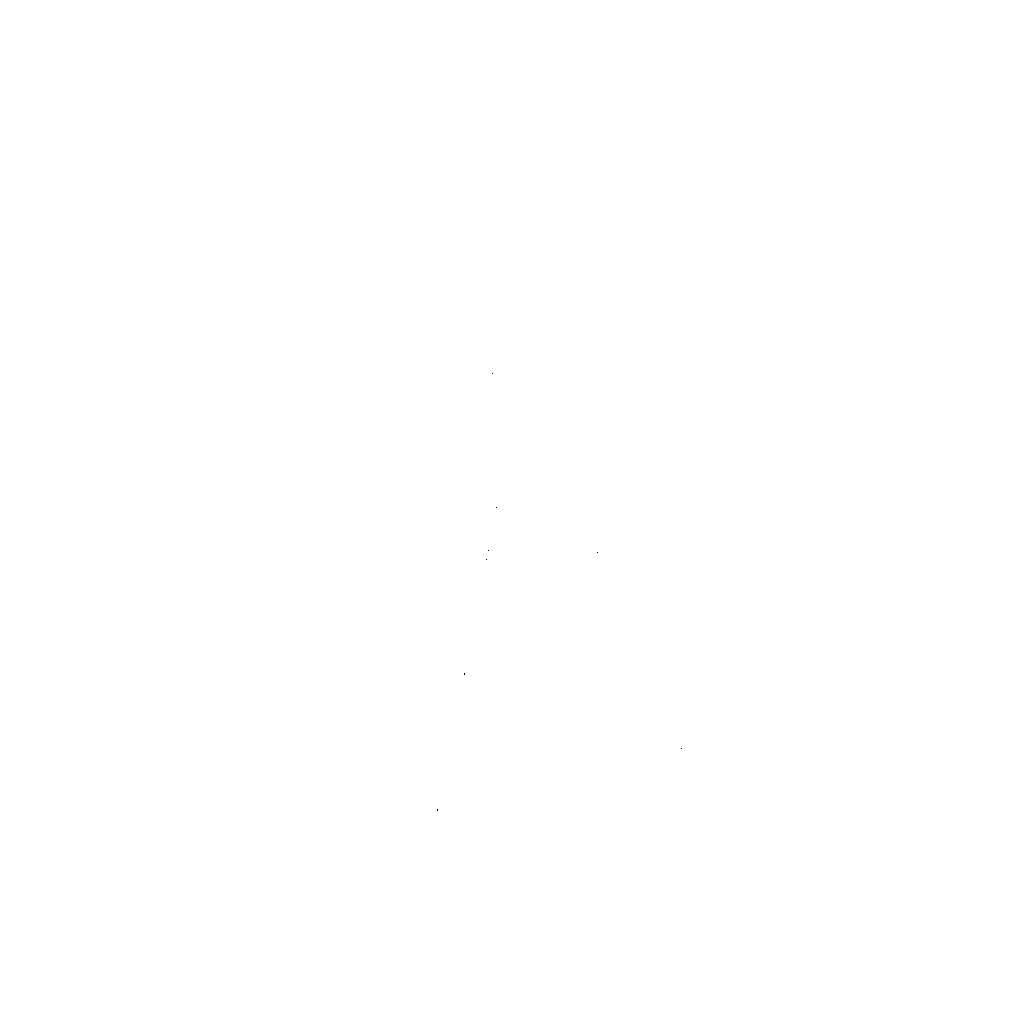

Threshold value: 50


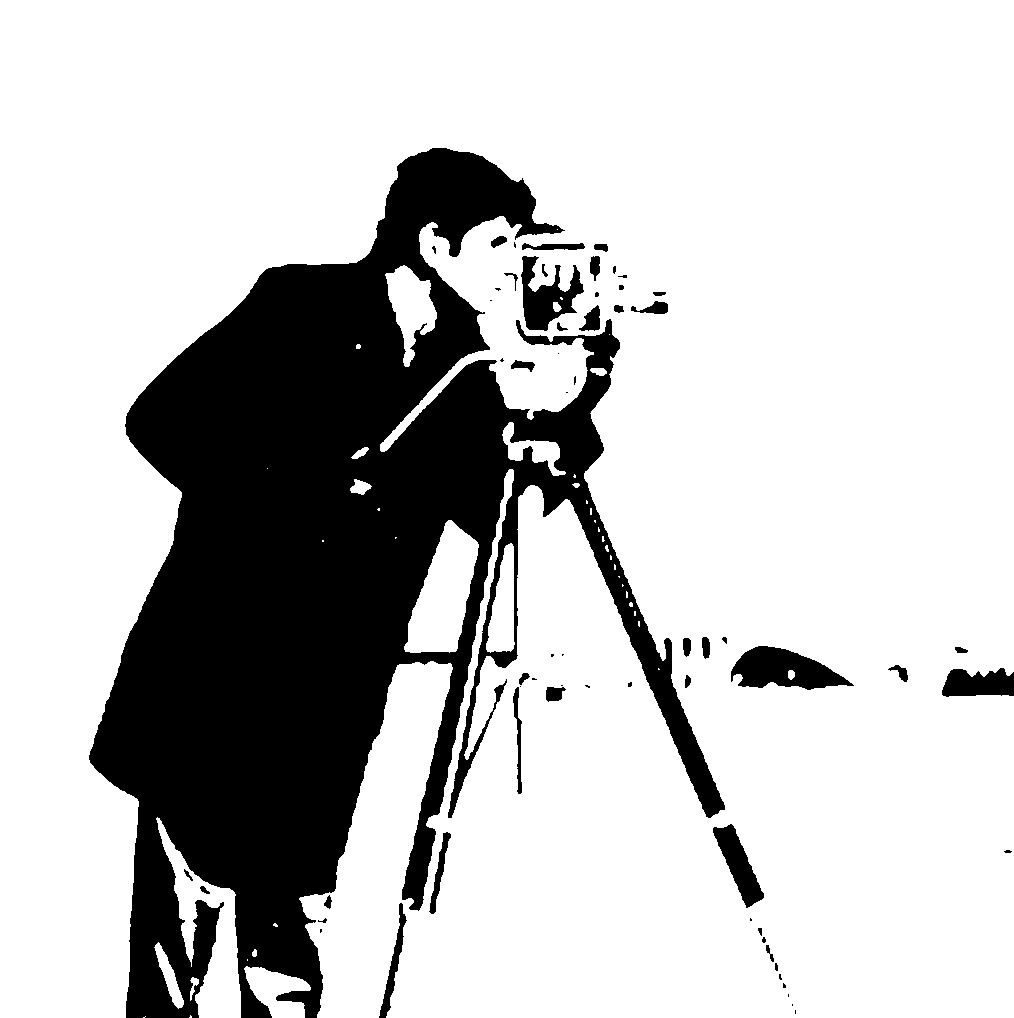

Threshold value: 100


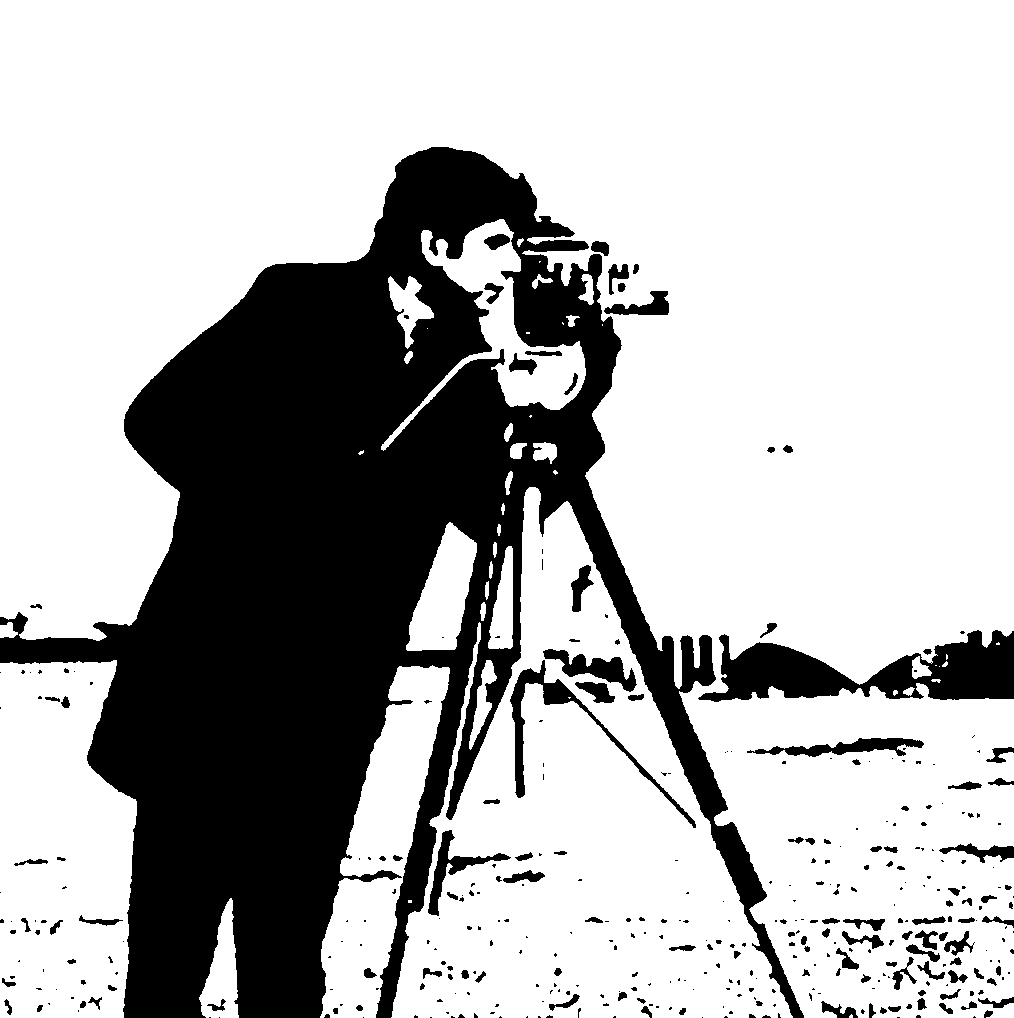

Threshold value: 150


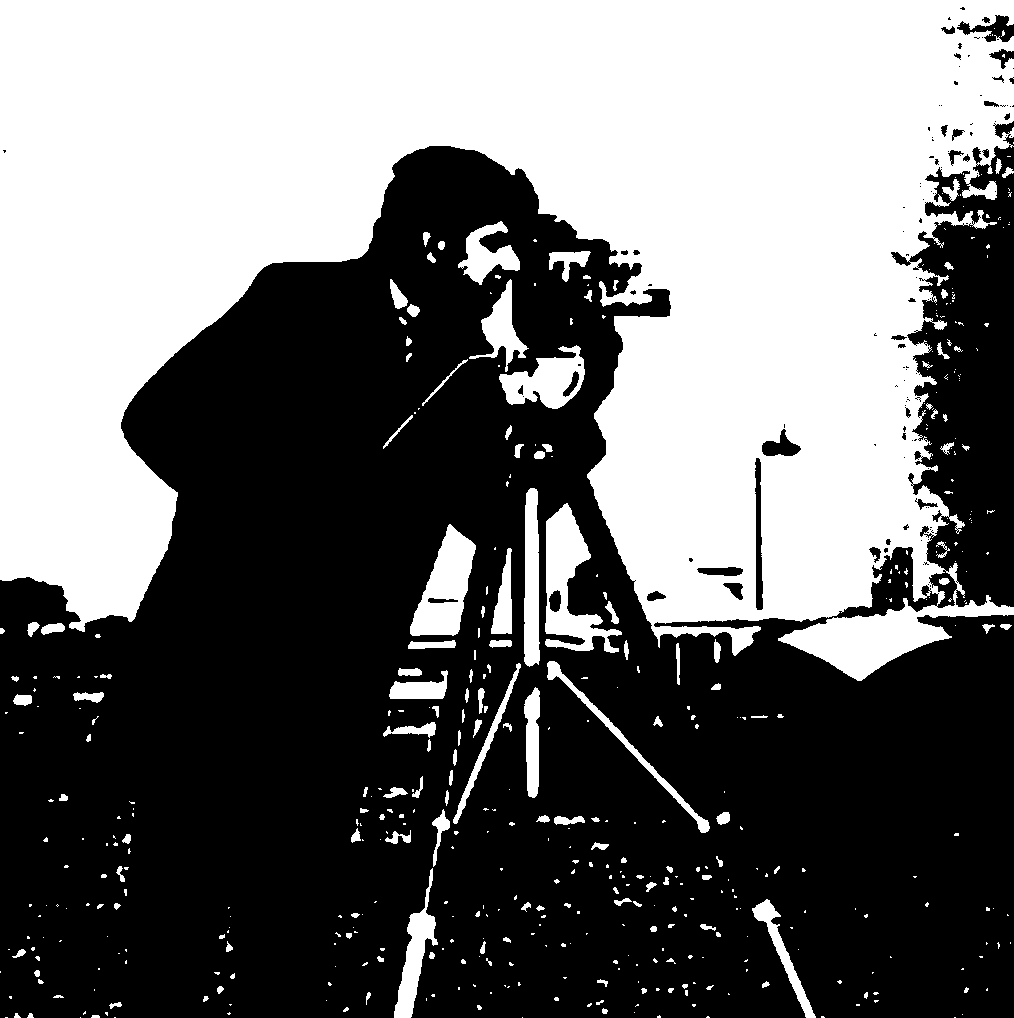

Threshold value: 200


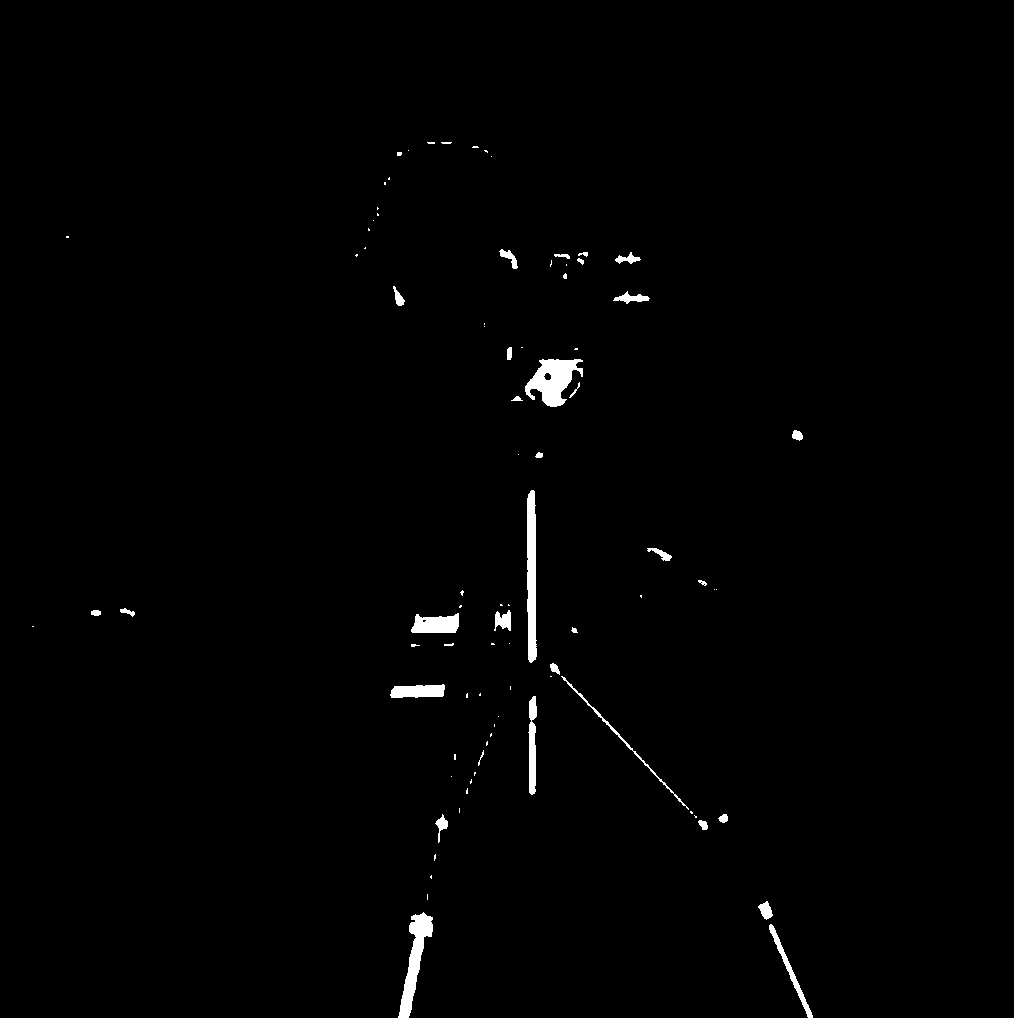

In [ ]:
import cv2

# Load the image in grayscale
img = cv2.imread('cameraman.png', cv2.IMREAD_GRAYSCALE)

# Set the threshold values
threshold_values = [0, 50, 100, 150, 200]

# Apply thresholding with different threshold values
for threshold_value in threshold_values:
    ret_thresh_value, thresh_img = cv2.threshold(img, threshold_value, 255, cv2.THRESH_BINARY)

    print(f"Threshold value: {threshold_value}")
    cv2_imshow(thresh_img)

Original Image: 


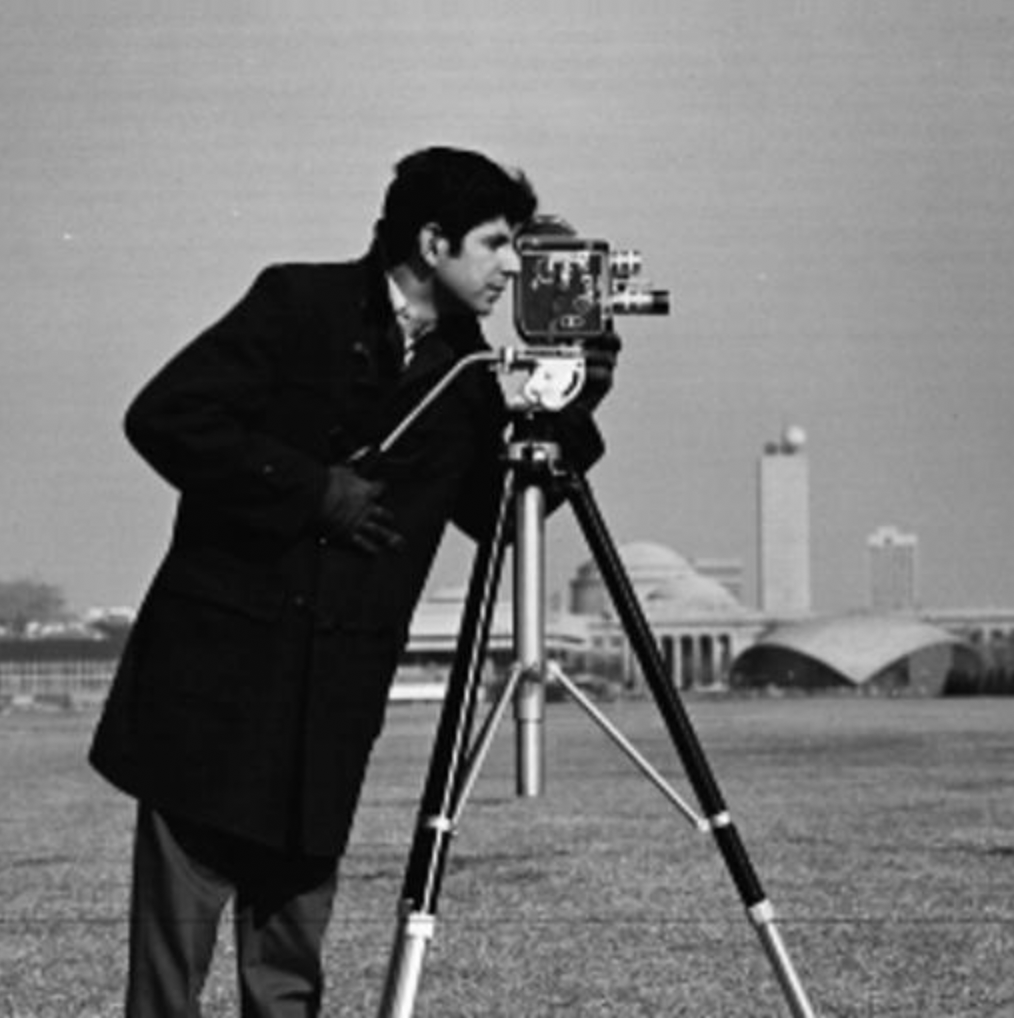

In [ ]:
print("Original Image: ")
cv2_imshow(img)

## Histograms

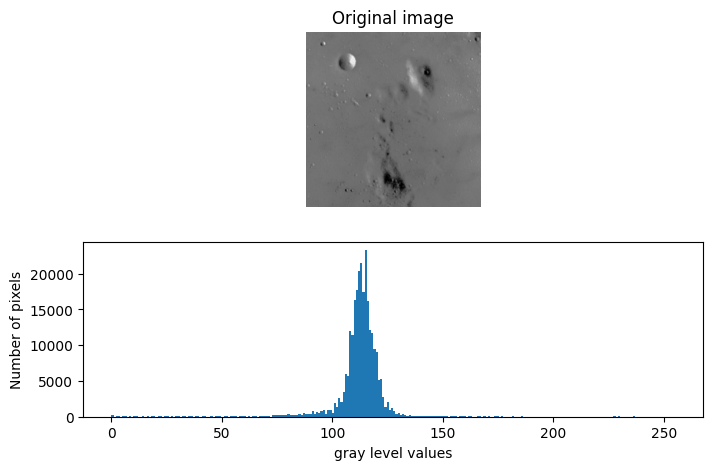

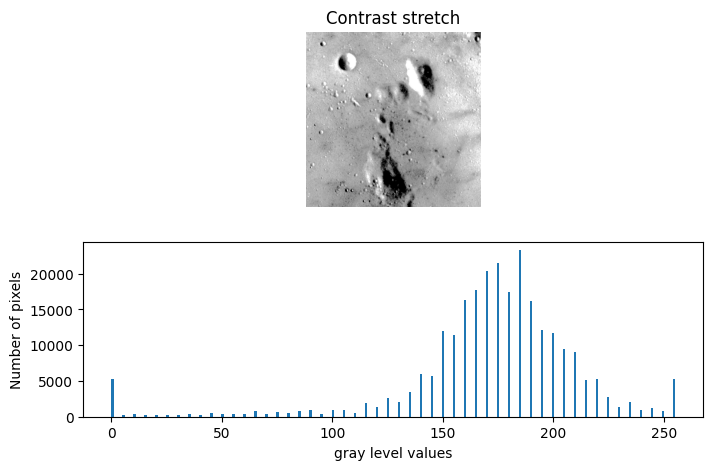

In [ ]:
# Task#2: Histogram Processing

# Step#1: Load necessary libraries
import matplotlib
import matplotlib.pyplot as plt
import numpy as np

from skimage import data
from skimage import exposure

# Step#2: Load moon image
img = data.moon()

# Step#3: Rescale intensity values to include all the intensities that fall within the 2nd and 98th percentiles
# Contrast stretching
p2, p98 = np.percentile(img, (2, 98))
img_rescale = exposure.rescale_intensity(img, in_range=(p2, p98))

# Step#4: Display the image with its histogram of (step#2)  and (step#3)
fig = plt.figure(figsize=(8, 5))
fig.add_subplot(2, 1, 1)
plt.imshow(img, cmap = 'gray')
plt.axis('off')
plt.title('Original image')

fig.add_subplot(2, 1, 2)
plt.hist(img.flat, bins = 256, range=(0, 255))
plt.xlabel('gray level values')
plt.ylabel('Number of pixels')
plt.show()

fig = plt.figure(figsize=(8, 5))
fig.add_subplot(2, 1, 1)
plt.imshow(img_rescale, cmap = 'gray')
plt.axis('off')
plt.title('Contrast stretch')

fig.add_subplot(2, 1, 2)
plt.hist(img_rescale.flat, bins = 256, range=(0, 255))
plt.xlabel('gray level values')
plt.ylabel('Number of pixels')
plt.show()

# Tasks:

Task1: Using the same ‘moon image’ Rescale intensity values to include all the intensities that fall within the 3nd and 80th percentiles, and plot the histogram

Task2: Using the same ‘moon image’ and the exposure.equalize_hist function, display the image and the histogram of the image after flattening the histogram.

Task3: Use the rocket (as reference) and chelsea images (from skimage.data) and implement histogram matching


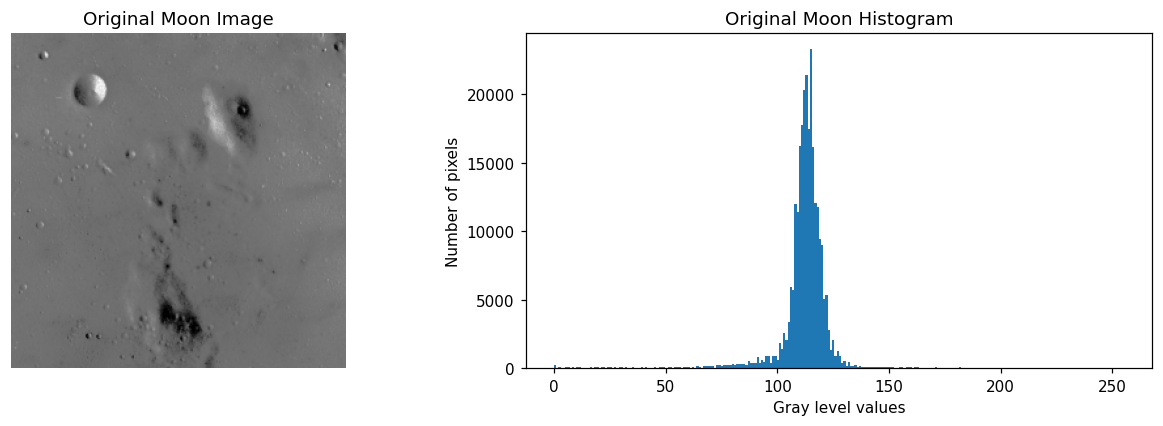

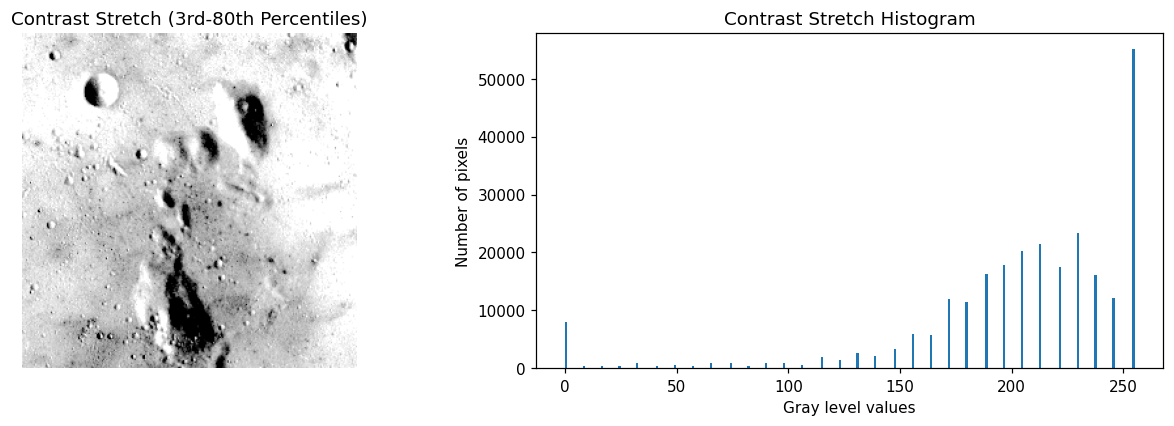

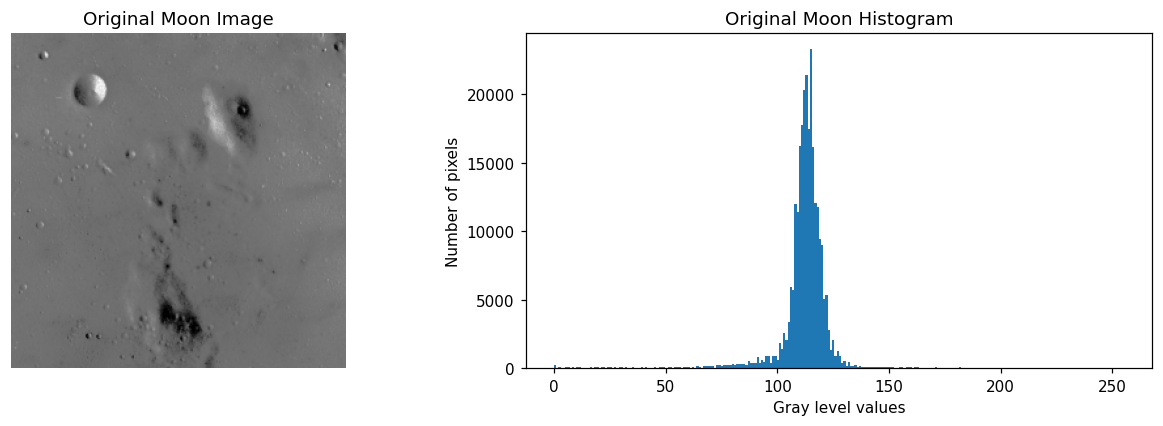

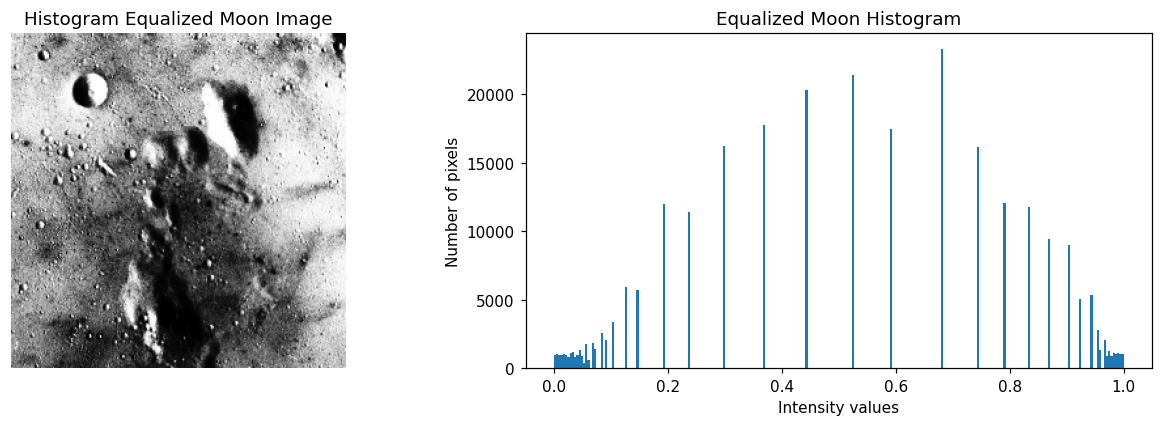

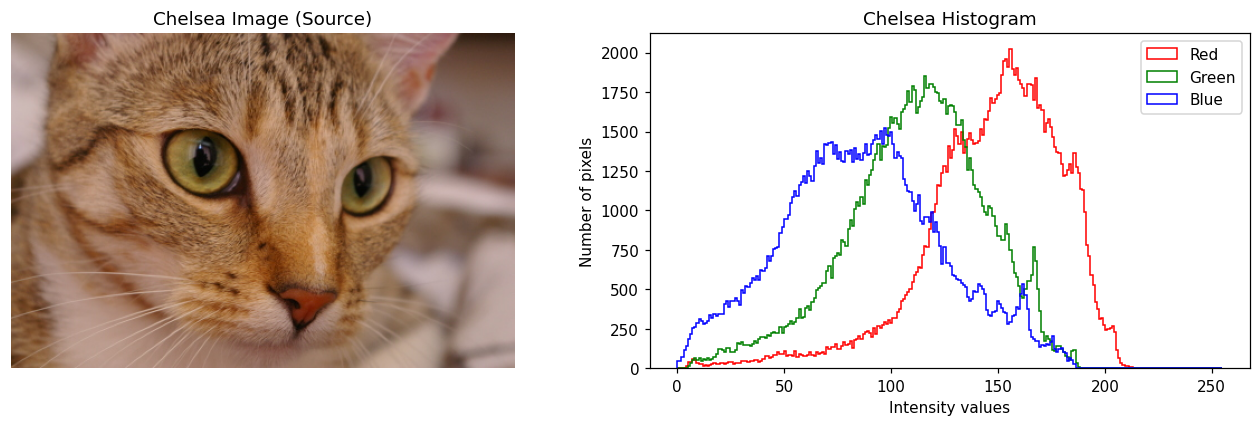

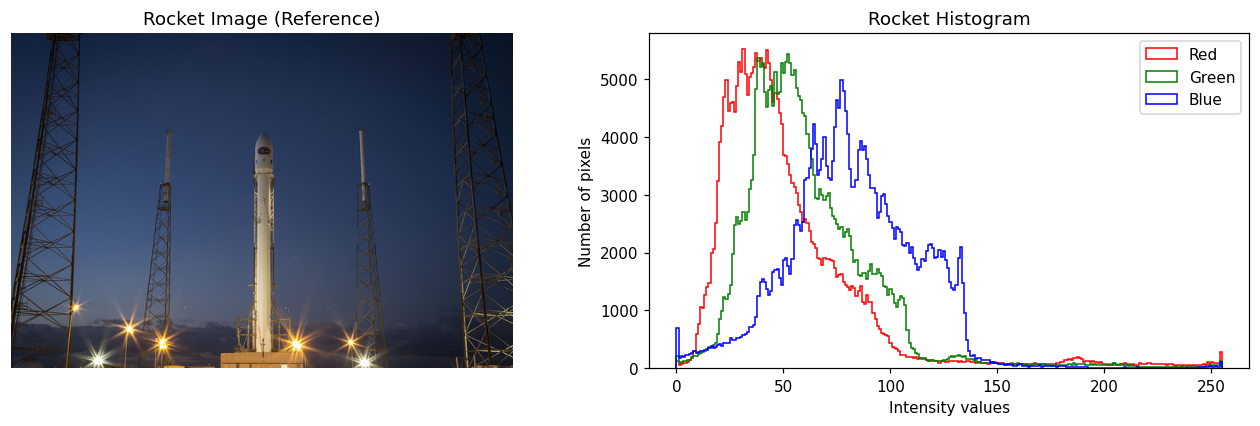

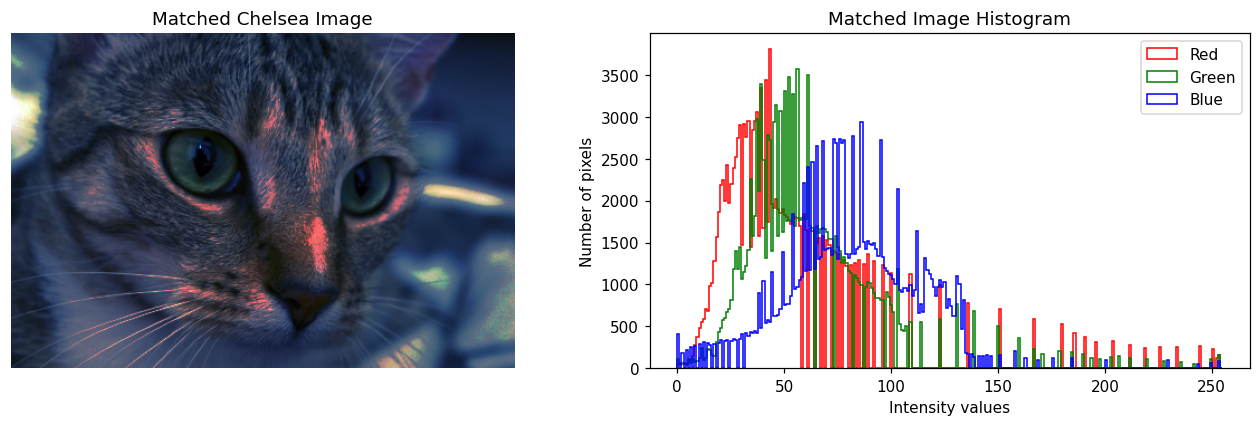

In [1]:
# =============================
# COMPLETE SOLUTION - ALL TASKS
# =============================

import numpy as np
import matplotlib.pyplot as plt
from skimage import data, exposure

# -------------------------------------------------
# Task 1: Contrast stretching - 3rd to 80th percentile
# -------------------------------------------------
moon = data.moon()
p3, p80 = np.percentile(moon, (3, 80))
moon_rescale = exposure.rescale_intensity(moon, in_range=(p3, p80))

# Original moon image + histogram
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].imshow(moon, cmap='gray')
ax[0].set_title('Original Moon Image')
ax[0].axis('off')
ax[1].hist(moon.ravel(), bins=256, range=(0, 255))
ax[1].set_title('Original Moon Histogram')
ax[1].set_xlabel('Gray level values')
ax[1].set_ylabel('Number of pixels')
plt.tight_layout()
plt.show()

# Rescaled moon image + histogram
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].imshow(moon_rescale, cmap='gray')
ax[0].set_title('Contrast Stretch (3rd-80th Percentiles)')
ax[0].axis('off')
ax[1].hist(moon_rescale.ravel(), bins=256, range=(0, 255))
ax[1].set_title('Contrast Stretch Histogram')
ax[1].set_xlabel('Gray level values')
ax[1].set_ylabel('Number of pixels')
plt.tight_layout()
plt.show()

# -------------------------------------------------
# Task 2: Histogram equalization
# -------------------------------------------------
moon_equalized = exposure.equalize_hist(moon)

# Original moon image + histogram
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].imshow(moon, cmap='gray')
ax[0].set_title('Original Moon Image')
ax[0].axis('off')
ax[1].hist(moon.ravel(), bins=256, range=(0, 255))
ax[1].set_title('Original Moon Histogram')
ax[1].set_xlabel('Gray level values')
ax[1].set_ylabel('Number of pixels')
plt.tight_layout()
plt.show()

# Equalized moon image + histogram
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].imshow(moon_equalized, cmap='gray')
ax[0].set_title('Histogram Equalized Moon Image')
ax[0].axis('off')
ax[1].hist(moon_equalized.ravel(), bins=256, range=(0, 1))
ax[1].set_title('Equalized Moon Histogram')
ax[1].set_xlabel('Intensity values')
ax[1].set_ylabel('Number of pixels')
plt.tight_layout()
plt.show()

# -------------------------------------------------
# Task 3: Histogram matching - Chelsea to Rocket
# Rocket = reference, Chelsea = source
# -------------------------------------------------
chelsea = data.chelsea()
rocket = data.rocket()
matched = exposure.match_histograms(chelsea, rocket, channel_axis=-1)

def show_color_image_and_histogram(image, image_title, histogram_title):
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    ax[0].imshow(image)
    ax[0].set_title(image_title)
    ax[0].axis('off')

    channel_names = ['Red', 'Green', 'Blue']
    line_colors = ['r', 'g', 'b']
    for channel, (name, color) in enumerate(zip(channel_names, line_colors)):
        ax[1].hist(image[:, :, channel].ravel(), bins=256, range=(0, 255),
                   histtype='step', color=color, label=name)
    ax[1].set_title(histogram_title)
    ax[1].set_xlabel('Intensity values')
    ax[1].set_ylabel('Number of pixels')
    ax[1].legend()
    plt.tight_layout()
    plt.show()

# Chelsea source image + its histogram
show_color_image_and_histogram(
    chelsea,
    'Chelsea Image (Source)',
    'Chelsea Histogram'
)

# Rocket reference image + its histogram
show_color_image_and_histogram(
    rocket,
    'Rocket Image (Reference)',
    'Rocket Histogram'
)

# Matched Chelsea image + its histogram
show_color_image_and_histogram(
    matched,
    'Matched Chelsea Image',
    'Matched Image Histogram'
)
